In [31]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [32]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap
from pathlib import Path
from typing import List
from matplotlib.patches import Patch
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.optimize import nnls
#import matplotlib.colormaps as cm
import matplotlib.markers as mmarkers
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# For PDPs
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import OneHotEncoder
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import math
from sklearn.model_selection import GridSearchCV
from scipy.stats import pearsonr
import shap
from sklearn.cross_decomposition import PLSRegression

In [33]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03", 
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")
lidar_files = collect_files(base_dir, dirs, "non-core", "met*.nc")
core_processed_files_cloud = collect_files(base_dir, dirs, "core_processed", "core-cloud*r0*.nc")
#core-cloud-phy_faam_20120920_v500_r0_b737#

# Example: print or pass them into other analysis
# print(core_processed_files)


In [34]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_core = {extract_flight_number(f) for f in core_processed_files}
flights_ams = {extract_flight_number(f) for f in dry_neph_files}
flights_sp2 = {extract_flight_number(f) for f in sp2_files}
flights_neph = {extract_flight_number(f) for f in ams_files}
flights_cloud = {extract_flight_number(f) for f in core_processed_files_cloud}

# Find flights that are in all three datasets
common_flights = flights_core & flights_ams & flights_sp2 & flights_neph & flights_cloud # Set intersection

# Filter the file lists to include only matching flights
filtered_core = [f for f in core_processed_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in ams_files if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in sp2_files if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in dry_neph_files if extract_flight_number(f) in common_flights]
filtered_cloud = [f for f in core_processed_files_cloud if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered Core files: {len(filtered_core)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_neph)}")
print(f"Filtered Cloud files: {len(filtered_cloud)}")

Common flights: ['b734', 'b737', 'b739', 'b742', 'b743', 'b744', 'b745', 'b746', 'b748', 'b749']
Filtered Core files: 10
Filtered AMS files: 10
Filtered SP2 files: 10
Filtered Neph files: 10
Filtered Cloud files: 10


In [35]:
def geometric_mean_diameter(D_lower, D_upper, concentrations):
    """
    Compute geometric mean diameter (µm) from channel boundaries and concentrations.
    """
    # Bin midpoints in log-space
    D_mid = np.sqrt(D_lower * D_upper)

    # Ensure concentrations is numpy array and mask invalids
    concentrations = np.array(concentrations, dtype=float)
    mask = (concentrations > 0) & (concentrations != 9999)

    if not np.any(mask):
        #print('retornou')
        return np.nan  # no valid data

    conc = concentrations[mask]
    D_mid = D_mid[mask]

    # Weighted geometric mean
    log_Dg = np.nansum(conc * np.log(D_mid)) / np.nansum(conc)
    return np.exp(log_Dg)

In [36]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_mid_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds_t = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds_t])

    dsf = dsf.assign_coords(time=dsf['neph_spm'])
    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))
    #dsf["Times"] = (("time",), datetime_values)
    #dsf["datetime"] = (("time",), datetime_values)
    #dsf = dsf.set_coords('neph_spm')

    return dsf

In [37]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [38]:
def Nc_file_treatment_v2(aux_ds_sp2, aux_ds_ams, aux_ds_psap):

    variables = ["SO4", "NH4", "ORG", "NO3", "Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    # Prepare individual valid masks and apply them
    resampled_vars = {}
    resampled_uncs = {}

    for var in variables:
        valid_mask = (aux_ds_ams[var] != 9999999) & (aux_ds_ams[var] >= 0)
        filtered = aux_ds_ams[var].where(valid_mask)
        resampled_vars[var] = filtered.resample(datetime="1min").mean()

    for unc in variables_unc:
        resampled_uncs[unc] = aux_ds_ams[unc].resample(datetime="1min").mean()

    # Process BC_mass
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2["BC_mass"].where(valid_BC_mass_mask) * 1e-3  # Convert to µg/m³
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    # Sum only valid AMS components at each time
    total_mass_ams = sum(v.fillna(0) for v in resampled_vars.values())

    # Sum only available AMS uncertainties (quadrature)
    total_uncertainty_ams = np.sqrt(sum((resampled_uncs[unc].fillna(0))**2 for unc in variables_unc))

    # Total BC mass (only one component here)
    total_mass_bc = resampled_ds_sp2

    # Combine AMS + BC total mass
    total_mass = total_mass_ams + total_mass_bc

    # PSAP filtering
    resampled_psap = aux_ds_psap.resample(Time='1min').mean()
    valid_PSAP_mask = (
        (resampled_psap["CO_AERO_FLAG"] == 0) 
#        (resampled_psap["CO_AERO"] >= 160) &
#        (resampled_psap["GPS_ALT"] <= 3000) &
#        (resampled_psap["GPS_ALT"] >= 200)
    )
    filtered_ds_psap = resampled_psap.where(valid_PSAP_mask, drop=False)
    filtered_ds_psap_aux = resampled_psap.where(valid_PSAP_mask, drop=True)

    # Match times
    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])
    total_mass_matched = total_mass.sel(time=common_times)
    total_mass_matched_uncertainty = total_uncertainty_ams.sel(time=common_times)
    #ds_psap_matched = filtered_ds_psap.sel(data_point=common_times)

    # Create auxiliary PSAP dataset with matching times
    psap_time = filtered_ds_psap_aux['data_point'].values
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    ds_psap_matched_aux = filtered_ds_psap_aux.where(mask, drop=True)

    # Optional mass breakdowns
    amonium_sulfate_nitrate = (
        resampled_vars["SO4"] +
        resampled_vars["NH4"] +
        resampled_vars["NO3"]
    )
    org = resampled_vars["ORG"]
    bc_mass = resampled_ds_sp2

    data_masses = [bc_mass, amonium_sulfate_nitrate, org]

    return ds_psap_matched_aux, total_mass_matched, total_mass_matched_uncertainty, ds_psap_matched_aux, data_masses


In [39]:
def file_ams_sp2_treatment_v3(aux_ds_sp2, aux_ds_ams):
    """
    Process AMS and SP2 datasets:
    - Filter invalid values
    - Exclude points where uncertainty > 0.5 * value
    - Resample to 1 min averages
    - Propagate uncertainties
    - Compute ammonium sulfate and nitrate mass concentrations
    """
    variables = ["SO4", "NH4", "ORG", "NO3", "Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]

    resampled_vars = {}
    resampled_uncs = {}

    for var, var_unc in zip(variables, variables_unc):
        # Mask invalid data
        valid_mask = (aux_ds_ams[var] != 9999999) & (aux_ds_ams[var_unc] != 9999999)

        # Additional restriction: only accept if uncertainty < 0.5 × value
        valid_mask &= aux_ds_ams[var_unc] < 0.5 * aux_ds_ams[var]

        data = aux_ds_ams[var].where(valid_mask)
        unc = aux_ds_ams[var_unc].where(valid_mask)

        # Resample (1 min mean)
        resampled_vars[var] = data.resample(datetime="1min").mean()

        # Count of valid points
        counts = data.resample(datetime="1min").count()

        # Propagate uncertainty: σ_mean = sqrt(sum(σ_i²)) / N
        sum_unc_sq = (unc ** 2).resample(datetime="1min").sum()
        resampled_uncs[var_unc] = np.sqrt(sum_unc_sq) / counts

    # Combine all processed variables
    resampled_ds_ams = xr.Dataset({**resampled_vars, **resampled_uncs})

    # --- Add derived variables ---
    # (NH4)2SO4 = 1.375 * SO4
    resampled_ds_ams["NH4_2SO4"] = 1.375 * resampled_ds_ams["SO4"]

    # NH4NO3 = 1.292 * NO3
    resampled_ds_ams["NH4NO3"] = 1.292 * resampled_ds_ams["NO3"]

    # Process BC_mass
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2["BC_mass"].where(valid_BC_mass_mask) * 1e-3  # Convert to µg/m³
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    return resampled_ds_ams, resampled_ds_sp2

In [40]:
def compute_pm_ratio(ds_core_cloud, density=1.8):
    """
    Compute PM_fine, PM_coarse, and their ratio from PCASP data.
    
    Parameters
    ----------
    ds_core_cloud : xarray.Dataset
        Dataset containing PCASP channels and diameter limits.
    density : float, optional
        Assumed particle density in g/cm³ (default = 1.8).
    
    Returns
    -------
    pm_ratio : xarray.DataArray
        Time series of PM_fine / PM_coarse ratio (unitless).
    pm_fine_1min : xarray.DataArray
        Time series of PM_fine (µg/m³).
    pm_coarse_1min : xarray.DataArray
        Time series of PM_coarse (µg/m³).
    """

    # --- Collect PCASP channels ---
    pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
    da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")
    da_pcasp = da_pcasp.where(da_pcasp != 9999)  # remove fill values (#/cm³)

    # --- Bin geometry ---
    D_lower = ds_core_cloud["PCAS2_D_L_NOM"].values
    D_upper = ds_core_cloud["PCAS2_D_U_NOM"].values
    D_mid = (D_lower + D_upper) / 2.0  # µm

    # --- Particle volume (µm³) per particle (sphere assumption) ---
    V_particle = (np.pi / 6.0) * (D_mid**3)
    da_V_particle = xr.DataArray(V_particle, dims=["PCAS2CH"], coords={"PCAS2CH": da_pcasp["PCAS2CH"]})

    # --- Volume and mass concentration ---
    vol_conc_bins = da_pcasp * da_V_particle  # µm³/cm³
    mass_conc_bins = vol_conc_bins * density  # µg/m³ per bin

    # --- Define fine and coarse ranges ---
    mask_fine = (D_mid <= 1.0)
    mask_coarse = (D_mid > 1.0) & (D_mid <= 3.0)

    # --- Integrate by size range ---
    PM_fine = mass_conc_bins.sel(PCAS2CH=mask_fine).sum(dim="PCAS2CH", skipna=True)
    PM_coarse = mass_conc_bins.sel(PCAS2CH=mask_coarse).sum(dim="PCAS2CH", skipna=True)

    # --- Resample (30 s averages) ---
    PM_fine_1min = PM_fine.resample(PCAS2TSPM="1min").mean(skipna=True)
    PM_coarse_1min = PM_coarse.resample(PCAS2TSPM="1min").mean(skipna=True)

    # --- Compute ratio ---
    pm_ratio = PM_coarse_1min

    return pm_ratio

In [41]:
def growth_func_calc(ds_nc):
    
    # Extract the dew point and time
    T_dew_K = ds_nc['TDEW_GE']  # Dew point temperature in Kelvin
    time = ds_nc['data_point']  # Time variable
    # Extract the True air temperature and time
    T_air_K = ds_nc['TAT_DI_R']  # True air temperature in Kelvin with shape (20998, 32)
    
    # Convert 'Time' to a pandas datetime index for resampling
    # Ensure the 'Time' variable is in seconds or a similar time unit that pandas can work with
    time_index = pd.to_datetime(time.values, unit='s')
    
    T_dew_flat = T_dew_K.values.flatten()
    time_flat_dew = time_index.repeat(T_dew_K.shape[1])  # Repeat the time values for each frequency (4Hz)
    
    
    # Create a pandas DataFrame for easier resampling
    df = pd.DataFrame({'Time': time_flat_dew, 'TDEW_GE': T_dew_flat})
    
    # Resample the data by 1 minute and calculate the mean for each interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Convert the resampled dew point temperature back to an xarray
    T_dew_resampled = xr.DataArray(df_resampled['TDEW_GE'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})
    
    # Step 2: Create a pandas DataFrame for resampling
    # Flatten the TAT_DI_R array to make it 1D for DataFrame construction
    T_air_flat = T_air_K.values.flatten()
    time_flat_air = time_index.repeat(T_air_K.shape[1])  # Repeat the time values for each frequency (32Hz)
    
    # Create a DataFrame with the flattened arrays
    df = pd.DataFrame({'Time': time_flat_air, 'TAT_DI_R': T_air_flat})
    
    # Step 3: Resample the data by 1 minute and compute the mean for each time interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Step 4: Convert back to xarray
    T_air_resampled = xr.DataArray(df_resampled['TAT_DI_R'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})

    # Convert from Kelvin to Celsius
    T_dew_resampled_C = T_dew_resampled - 273.15
    
    # Convert from Kelvin to Celsius
    T_air_resampled_C = T_air_resampled - 273.15
    
    # Convert to Celsius
    T_dew_C = T_dew_resampled_C
    T_air_C = T_air_resampled_C
    
    # Calculate relative humidity using the Magnus formula
    RH = 100 * (np.exp((17.625 * T_dew_C) / (243.04 + T_dew_C)) /
                np.exp((17.625 * T_air_C) / (243.04 + T_air_C)))

    alpha = 0.15
    fh = (1-(RH)/100)**(-alpha)


    return fh,RH

In [42]:
def calculate_scatering_eff_v2(aux_ds_sp2,aux_ds_ams,aux_ds_neph):

    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ams = filtered_ds.resample(datetime="1min").mean()
    resampled_neph = aux_ds_neph.resample(datetime='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ams[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc

    # Compute total uncertainty (quadrature sum)
    total_uncertainty_ams = np.sqrt(sum((resampled_ams[unc] ** 2 for unc in variables_unc)))
    total_uncertainty = total_uncertainty_ams  # Assuming BC_mass has no uncertainty provided

    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])

    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_neph_matched = resampled_neph.sel(time=common_times)
    total_mass_matched_uncertanty = total_uncertainty.sel(time=common_times)

    
    return ds_neph_matched,total_mass_matched,total_mass_matched_uncertanty

In [43]:
def extract_pcasp_geo_diameter(ds_core_cloud):
    """
    Compute geometric mean diameters from PCASP channels in ds_core_cloud.
    
    Parameters
    ----------
    ds_core_cloud : xarray.Dataset
        Dataset containing PCASP variables:
        - PCAS2_01 ... PCAS2_30
        - PCAS2_D_L_NOM, PCAS2_D_U_NOM
        - PCAS2TSPM (time coordinate)
    geometric_mean_diameter_func : callable
        Function to compute geometric mean diameter given
        (D_lower_limits, D_upper_limits, concentrations).
    
    Returns
    -------
    times : np.ndarray
        Array of time values.
    Dgs : np.ndarray
        Array of geometric mean diameters.
    """

    # Collect PCASP channels into one DataArray (channels x time)
    pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
    da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")

    # Replace invalid values (9999) with NaN
    da_pcasp = da_pcasp.where(da_pcasp != 9999)

    # Diameter bin limits
    D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values
    D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values

    # Loop through time to compute geometric mean diameters
    times = da_pcasp['PCAS2TSPM'].values
    geom_diam_list = []

    for t in times:
        snapshot = da_pcasp.sel(PCAS2TSPM=t)
        concentrations = snapshot.values
        Dg = geometric_mean_diameter(D_lower_limits, D_upper_limits, concentrations)
        geom_diam_list.append((t, Dg))

    # Unpack times and diameters
    times, Dgs = zip(*geom_diam_list)
    return da_pcasp, times, Dgs

In [44]:
def compute_coarse_fraction(ds_core_cloud) :
    """
    Compute the percentage of coarse particles (>1 µm) relative to 
    the total particle concentration from PCASP data.
    
    Parameters
    ----------
    ds_core_cloud : xr.Dataset
        Dataset containing PCASP channels and diameter limits.
        
    Returns
    -------
    coarse_fraction_1min : xr.DataArray
        Time series of coarse particle fraction (%) resampled to 1-minute averages.
    """

    # Collect PCASP channels and remove invalid values
    pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
    da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")
    da_pcasp = da_pcasp.where(da_pcasp != 9999)  # remove fill values

    # Bin limits (µm)
    D_lower = ds_core_cloud['PCAS2_D_L_NOM'].values
    D_upper = ds_core_cloud['PCAS2_D_U_NOM'].values
    D_mid = (D_lower + D_upper) / 2.0  # mid diameters

    # Mask for coarse particles (>1 µm)
    mask_coarse = D_mid >= 1.0

    # Compute total and coarse concentrations (#/cm³)
    total_conc = da_pcasp.sum(dim="PCAS2CH", skipna=True)
    coarse_conc = da_pcasp.sel(PCAS2CH=mask_coarse).sum(dim="PCAS2CH", skipna=True)

    # Compute coarse fraction (%)
    coarse_fraction = (coarse_conc / total_conc) * 100.0

    # Resample to 1-minute averages
    coarse_fraction_1min = coarse_fraction.resample(PCAS2TSPM="1min").mean(skipna=True)
    coarse_conc = coarse_conc.resample(PCAS2TSPM="1min").mean(skipna=True)

    return coarse_fraction_1min, coarse_conc

In [45]:
results_sct_all = []

# Iterate over all matching flights
for sp2_file, ams_file, core_file, neph_file, cloud_file in zip(filtered_sp2, filtered_ams, filtered_core, filtered_neph,filtered_cloud):
    
    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    ds_core = xr.open_dataset(core_file)
    ds_core_cloud = xr.open_dataset(cloud_file)
    da_pcasp, times_cloud, Dgs = extract_pcasp_geo_diameter(ds_core_cloud)
    PM_ratio = compute_pm_ratio(ds_core_cloud)
    series = pd.Series(Dgs, index=pd.to_datetime(times_cloud))

    # Resample to 1-minute mean
    ams_resampled, sp2_resampled = file_ams_sp2_treatment_v3(ds_sp2,ds_ams)
    resampled_neph = ds_neph.resample(datetime='1min').mean()
    resampled_core = ds_core.resample(Time='1min').mean()
    resampled_core_filtered = resampled_core.where(resampled_core["CO_AERO_FLAG"] == 0, drop=True)
    Dgs_1min = series.resample("1min").mean()
    
    
    resampled_neph_time = resampled_neph["time"].values  # Reference timestamps
    ams_resampled_time = ams_resampled["time"].values
    sp2_resampled_time = sp2_resampled["time"].values
    resampled_core_time = resampled_core_filtered["data_point"].values
    
    
    #print(f"Number of timestamps Neph: {len(resampled_neph_time)}")
    #print(f"Number of timestamps AMS: {len(ams_resampled_time)}")
    #print(f"Number of timestamps SP2: {len(sp2_resampled_time)}")
    #print(f"Number of timestamps Dg: {len(Dgs_1min)}")
    #print(f"Number of timestamps core: {len(resampled_core_time)}")
    
    # First find common times between neph and AMS
    common_times = np.intersect1d(resampled_neph_time, ams_resampled_time)
    
    # Then intersect with SP2
    common_times = np.intersect1d(common_times, sp2_resampled_time)
    # Then intersect with CORE
    common_times = np.intersect1d(common_times, resampled_core_time)
    
    #print(f"Number of common timestamps: {len(common_times)}")
    
    
    core_file_matched = resampled_core_filtered.sel(data_point=common_times)
    ams_resampled_matched = ams_resampled.sel(time=common_times)
    sp2_resampled_matched = sp2_resampled.sel(time=common_times)
    resampled_neph_matched = resampled_neph.sel(time=common_times)
    Dg_aligned_matched = Dgs_1min.reindex(pd.to_datetime(common_times), method="nearest")
    PM_ratio_matched = PM_ratio.sel(PCAS2TSPM = common_times)
    GF, RH = growth_func_calc(core_file_matched)
    
    #Core file variables
    Height = core_file_matched['GPS_ALT'].values.squeeze()
    Lon = core_file_matched['LON_GPS'].values.squeeze()
    Lat = core_file_matched['LAT_GPS'].values.squeeze()
    CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
    PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()
    #Neph file variables
    TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()
    #Sp2 file variables
    BC = sp2_resampled_matched.values
    #AMS file variables
    ORG = ams_resampled_matched['ORG'].values
    ORG_unc = ams_resampled_matched['ORG_uncertainty'].values
    SO4 = ams_resampled_matched['SO4'].values
    SO4_unc = ams_resampled_matched['SO4_uncertainty'].values
    NH4 = ams_resampled_matched['NH4'].values
    NH4_unc = ams_resampled_matched['NH4_uncertainty'].values
    NO3 = ams_resampled_matched['NO3'].values
    NO3_unc = ams_resampled_matched['NO3_uncertainty'].values
    AS = ams_resampled_matched['NH4_2SO4'].values
    AN = ams_resampled_matched['NH4NO3'].values
    #PCASP variables
    Dg = Dg_aligned_matched
    ratio_pm = PM_ratio_matched
    
    #Secondary Inorganics
    SIC = SO4 + NH4 + NO3
    SIC_unc = np.sqrt(SO4_unc**2 + NH4_unc**2 + NO3_unc**2)
    
    #print('len BC:',len(BC))
    #print('len SIC:',len(SIC))
    #print('len Neph:',len(TSC_green))
    #print('len Dg:',len(Dg_aligned_matched))
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', core_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    
    results_sct_all.append({
        'ORG': ORG,
        'ORG_corrected': ORG,
        'ORG_UNC': ORG_unc,
        'BC': BC,
        'SO4': SO4,
        'SO4_corrected': SO4,
        'NH4': NH4,
        'NH4_corrected': NH4,
        'NO3': NO3,
        'NO3_corrected': NO3,
        'AS': AS,
        'AN': AN,
        'SO4_unc': SO4_unc,
        'NH4_unc': NH4_unc,
        'NO3_unc': NO3_unc,
        'SIC': SIC,
        'SIC_UNC': SIC_unc,
        'TSC_blue':TSC_blue,
        'TSC_green':TSC_green,
        'TSC_red':TSC_red,
        'ABS_PSAP':PSAP_matched,
        'DG_aligned': Dg,
        'PM_ratio': ratio_pm,
        'CO': CO_conc_matched,
        'ALT' : Height,
        'LON': Lon,
        'LAT': Lat,
        'RH': RH,
        'flight': flight_number
    })


In [46]:
# Combine all flight data
combined_data = []
for entry in results_sct_all:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'ABS_PSAP':entry['ABS_PSAP'],
            'BC': entry['BC'],
            'SO4': entry['SO4'],
            'SIC': entry['SIC'],
            'NH4': entry['NH4'],
            'NO3': entry['NO3'],
            'AS': entry['AS'],
            'AN': entry['AN'],
            'ORG': entry['ORG'],
            'DG': entry['DG_aligned'],
            'PM_coarse': entry['PM_ratio'],
            'ALT' : entry['ALT'],
            'LON': entry['LON'],
            'LAT': entry['LAT'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })

        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

In [47]:
def plot_rf_summary(top_features, y_test, y_pred, r2, rmse, 
                    features, df_clean, X_train, X_test):
    """
    Create a combined Random Forest summary figure including:
      (A) Feature importance bar plot
      (B) Predicted vs Measured scatter with R², RMSE, and slope
      (C) Summary table with model metrics and features used
    """

    fig = plt.figure(figsize=(14, 6))
    gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[3, 1])

    # --- (A) Feature importance bar plot ---
    ax1 = fig.add_subplot(gs[0, 0])
    top_features.plot(kind="bar", ax=ax1, color="steelblue", edgecolor="black")
    ax1.set_title("Top Feature Importances", fontsize=12)
    ax1.set_ylabel("Importance Score")
    ax1.tick_params(axis='x', rotation=45)

    # --- (B) Predicted vs Measured scatter ---
    ax2 = fig.add_subplot(gs[0, 1:])
    ax2.scatter(y_test, y_pred, alpha=0.6, s=30, color="tab:green", edgecolor="black", label="Data")

    # 1:1 reference line
    ax2.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label="1:1 line")

    # Linear regression fit (Predicted vs Measured)
    model = LinearRegression().fit(y_test.values.reshape(-1, 1), y_pred)
    slope = model.coef_[0]
    intercept = model.intercept_
    y_fit = model.predict(y_test.values.reshape(-1, 1))

    ax2.plot(y_test, y_fit, color="blue", lw=2,
             label=f"Linear fit (slope = {slope:.3f})")

    # Labels and grid
    ax2.set_xlabel("Measured TSC_green (×10⁶)")
    ax2.set_ylabel("Predicted TSC_green (×10⁶)")
    ax2.set_title("Random Forest Prediction")
    ax2.grid(True, linestyle="--", alpha=0.6)
    #ax2.legend(fontsize=9, loc="upper left", frameon=True)

    # Add regression metrics as text box
    textstr = f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f}\nSlope = {slope:.3f}"
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes,
             fontsize=11, verticalalignment='top', bbox=props)

    # --- (C) Table with model stats and features used ---
    ax3 = fig.add_subplot(gs[1, :])
    ax3.axis("off")

    summary_data = {
        "Metric": ["R²", "RMSE", "Slope", "n_features", "n_measurements", "Train size", "Test size"],
        "Value": [f"{r2:.3f}", f"{rmse:.2f}", f"{slope:.3f}",
                  len(features.columns), len(df_clean), len(X_train), len(X_test)]
    }
    summary_df = pd.DataFrame(summary_data)

    feature_list_df = pd.DataFrame({
        "Features": features.columns
    })

    table_data = pd.concat([feature_list_df, summary_df], axis=1).fillna('-')

    ax3.table(
        cellText=table_data.values,
        colLabels=[f"$\\bf{{{col}}}$" for col in table_data.columns],
        cellLoc="center",
        loc="center"
    )

    plt.tight_layout()
    plt.show()

In [48]:
def plot_manual_pdp_with_slopes(rf, X_train, feat_importances, target_label="Predicted TSC_green (×10⁶)"):
    """
    Compute and plot manual Partial Dependence Plots (PDP) with linear fits
    and display a summary table of slopes ± uncertainties.
    
    Parameters
    ----------
    rf : fitted RandomForestRegressor
        The trained random forest model.
    X_train : pandas.DataFrame
        The training feature matrix.
    feat_importances : pandas.Series
        Feature importances from the fitted model.
    target_label : str, optional
        Label for the Y-axis of PDP plots (default is 'Predicted TSC_green (×10⁶)').
    """
    
    all_features = feat_importances.sort_values(ascending=False).index.tolist()
    n_features = len(all_features)

    n_cols = 2
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(14, n_rows * 3),
        constrained_layout=True,
        sharey=False
    )
    axes = axes.ravel()

    slopes = {}
    slope_errors = {}

    for i, feat in enumerate(all_features):
        ax = axes[i]
        
        feat_values = X_train[feat].dropna()
        grid = np.linspace(feat_values.min(), feat_values.max(), 60)
        
        pdp_mean, pdp_std = [], []
        X_temp = X_train.copy()
        
        for val in grid:
            X_temp[feat] = val
            preds = rf.predict(X_temp)
            pdp_mean.append(np.mean(preds))
            pdp_std.append(np.std(preds))
        
        pdp_mean = np.array(pdp_mean)
        pdp_std = np.array(pdp_std)
        
        # Linear regression and slope uncertainty
        lr = LinearRegression().fit(grid.reshape(-1,1), pdp_mean)
        preds_fit = lr.predict(grid.reshape(-1,1))
        slope = lr.coef_[0]
        intercept = lr.intercept_
        
        n = len(grid)
        residuals = pdp_mean - preds_fit
        residual_var = np.sum(residuals**2) / (n - 2)
        slope_se = np.sqrt(residual_var / np.sum((grid - grid.mean())**2))
        
        slopes[feat] = slope
        slope_errors[feat] = slope_se
        
        # Plot PDP + fit
        ax.plot(grid, pdp_mean, color="steelblue", lw=2, label="Mean PDP")
        ax.fill_between(grid, pdp_mean - pdp_std, pdp_mean + pdp_std,
                        color="steelblue", alpha=0.2, label="±1σ range")
        ax.plot(grid, preds_fit, '--', color='red', lw=1.5, 
                label=f'Linear fit\nslope={slope:.3e} ± {slope_se:.1e}')
        
        ax.set_title(f"{feat}", fontsize=11)
        ax.set_xlabel(feat)
        ax.set_ylabel(target_label)
        ax.legend(fontsize=9, loc="lower right", frameon=True)
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)
        ax.grid(False, axis='x')
        ax.set_xscale("linear")

    # Hide extra subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Partial Dependence of TSC_green on All Features (Manual PDP)", fontsize=14, y=1.02)
    plt.show()

    # --- Table of slopes ± uncertainties ---
    fig, ax = plt.subplots(figsize=(7, len(slopes) * 0.5 + 1))
    ax.axis('off')

    slope_df = pd.DataFrame({
        'Feature': list(slopes.keys()),
        'Slope (±1σ)': [f"{s:.3e} ± {se:.1e}" for s, se in zip(slopes.values(), slope_errors.values())]
    })

    table = ax.table(
        cellText=slope_df.values,
        colLabels=slope_df.columns,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.3)

    ax.set_title("Slopes and Uncertainties from Linear Fits of Partial Dependence", fontsize=13, pad=10)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        'Feature': list(slopes.keys()),
        'Slope': list(slopes.values()),
        'Slope_SE': list(slope_errors.values())
    })

In [49]:
def plot_feature_histograms(X_train, feat_importances, p_low=10, p_high=99):
    """
    Plot histograms for all features in X_train with percentile reference lines.

    Parameters
    ----------
    X_train : pandas.DataFrame
        Training dataset containing the feature columns.
    feat_importances : pandas.Series
        Feature importance scores (used to order the plots).
    p_low : float, optional
        Lower percentile line (default=10).
    p_high : float, optional
        Upper percentile line (default=99).
    """
    all_features = feat_importances.sort_values(ascending=False).index.tolist()
    n_features = len(all_features)

    # Grid layout
    n_cols = 2
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(14, n_rows * 3),
        constrained_layout=True,
        sharey=False
    )
    axes = axes.ravel()

    for i, feat in enumerate(all_features):
        ax = axes[i]
        data = X_train[feat].dropna()
        
        # Compute percentiles
        p_low_val, p_high_val = np.percentile(data, [p_low, p_high])
        
        # Plot histogram
        ax.hist(data, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Add percentile lines
        ax.axvline(p_low_val, color='red', linestyle='--', lw=1.5, label=f"{p_low}th: {p_low_val:.2e}")
        ax.axvline(p_high_val, color='orange', linestyle='--', lw=1.5, label=f"{p_high}th: {p_high_val:.2e}")
        
        # Labels and legend
        ax.set_title(f"{feat} Distribution", fontsize=11)
        ax.set_xlabel(feat)
        ax.set_ylabel("Count")
        ax.legend(fontsize=8, loc="upper right", frameon=True)
        
        # Style: grid only on y-axis
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)
        ax.grid(False, axis='x')

    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Feature Distributions with {p_low}th & {p_high}th Percentiles", fontsize=14, y=1.02)
    plt.show()

In [50]:
# Flights to exclude
Selected_flights = ["b742"]

# Filter the DataFrame
df_filtered_flight = df_all[~df_all["Flight"].isin(Selected_flights)]
# Filter the DataFrame by geometric mean diameter
df_filtered_org = df_filtered_flight[(df_filtered_flight["ORG"] > 10)]
df_filtered_flight_co = df_filtered_flight[(df_filtered_flight["CO"] < 300)]
df_filtered_flight_co_as = df_filtered_flight[(df_filtered_flight["CO"] > 300)&(df_filtered_flight["AS"] > 1)]

In [67]:
# -----------------------------
# 1. Prepare dataset
# -----------------------------
df_clean = df_filtered_flight.replace([np.inf, -np.inf], np.nan).dropna()

# Features and target
features = df_clean.drop(columns=[
    'TSC_green','TSC_blue','TSC_red','Flight','ABS_PSAP','SIC','AS','AN'
])
target = (df_clean['TSC_green']) *1e6
#print(len(target))
# -----------------------------
# 2. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)

# -----------------------------
# 3. Fit Random Forest
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# -----------------------------
# 4. Evaluate model
# -----------------------------
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# -----------------------------
# 5. Feature importances
# -----------------------------
importances = rf.feature_importances_
feat_importances = pd.Series(importances, index=features.columns)
top_features = feat_importances.sort_values(ascending=False).head(11)

/tmp/ipykernel_366/202859426.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_matrix = corr_matrix.round(2).astype(str) + "\np=" + p_matrix.applymap(lambda x: f"{x:.3e}")


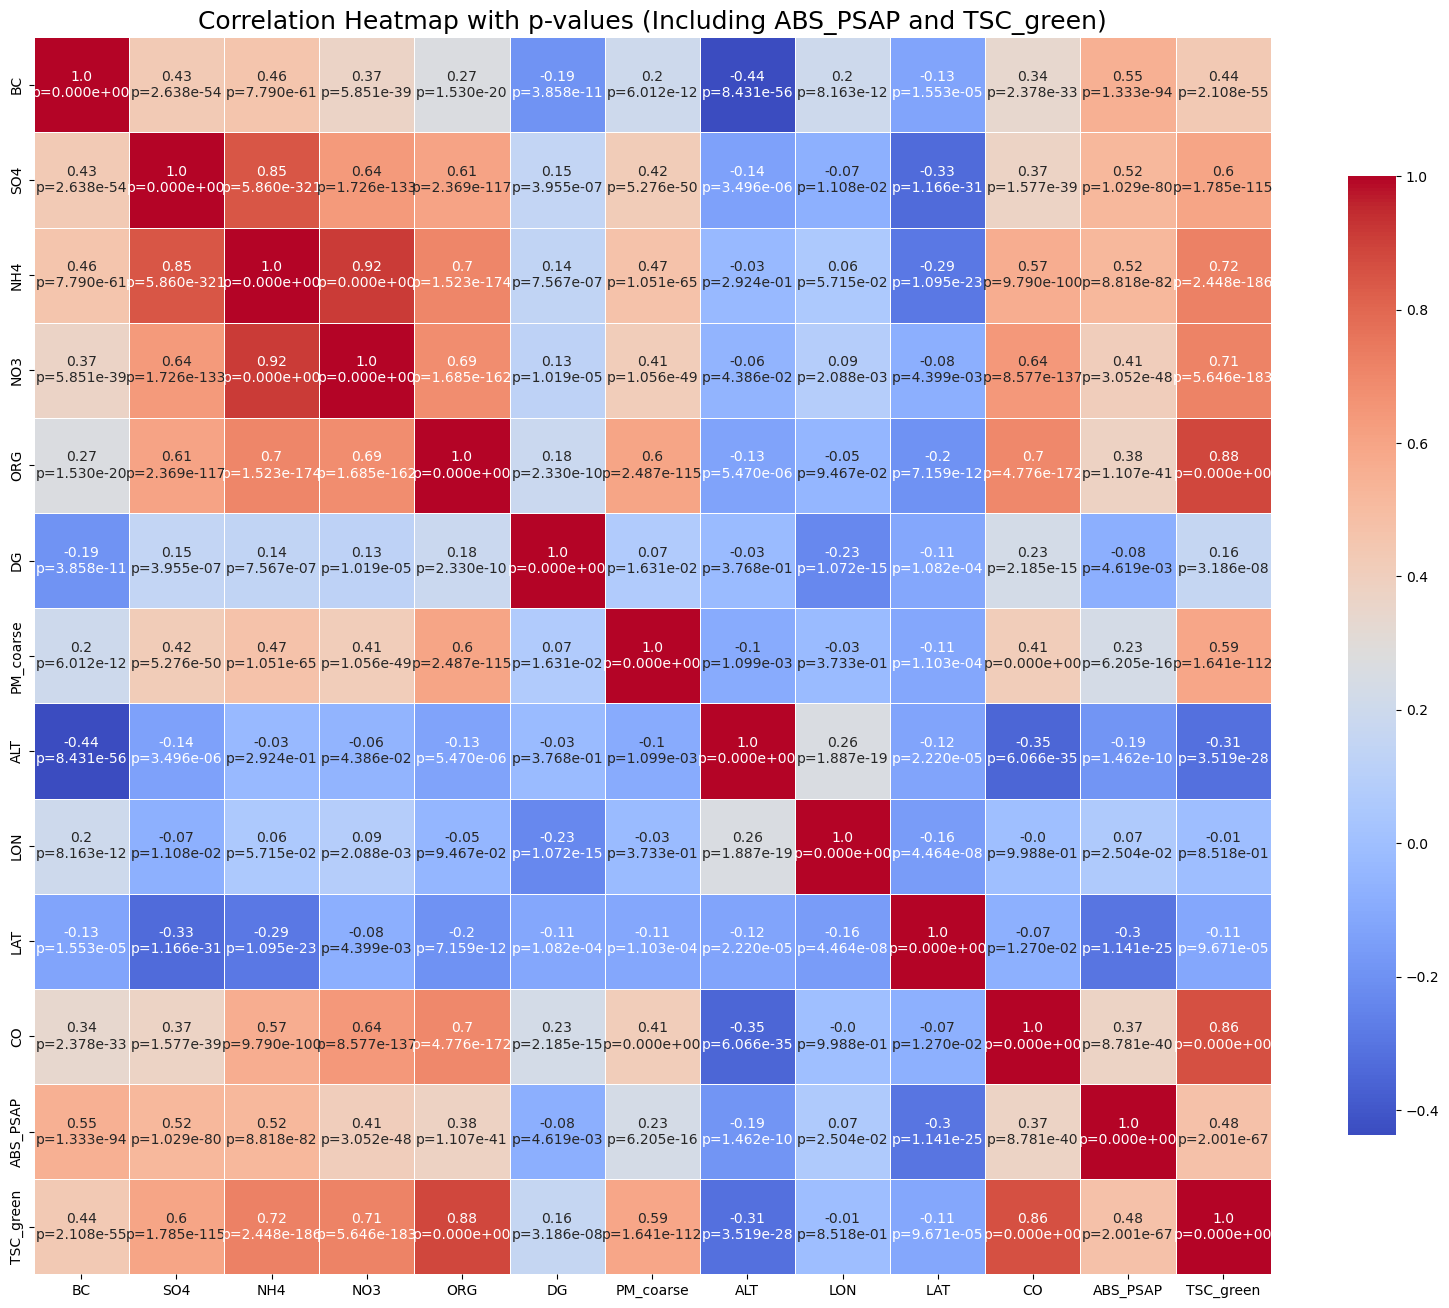

In [52]:
# -----------------------------------------------
# 1. Rebuild dataframe including ABS_PSAP and TSC_green
# -----------------------------------------------
corr_df = df_clean[features.columns.tolist() + ['ABS_PSAP', 'TSC_green']]

# -----------------------------------------------
# 2. Compute correlation matrix and p-value matrix
# -----------------------------------------------
corr_matrix = corr_df.corr(method='pearson')

# Initialize empty p-value matrix
p_matrix = pd.DataFrame(np.zeros_like(corr_matrix), columns=corr_matrix.columns, index=corr_matrix.index)

# Compute p-values
for row in corr_df.columns:
    for col in corr_df.columns:
        r, p = pearsonr(corr_df[row], corr_df[col])
        p_matrix.loc[row, col] = p

# -----------------------------------------------
# 3. Build annotation matrix: "r = XX\np = YY"
# -----------------------------------------------
annot_matrix = corr_matrix.round(2).astype(str) + "\np=" + p_matrix.applymap(lambda x: f"{x:.3e}")

# -----------------------------------------------
# 4. Plot heatmap
# -----------------------------------------------
plt.figure(figsize=(16, 14))

sns.heatmap(
    corr_matrix,
    annot=annot_matrix,    # Annotate correlations AND p-values
    fmt="",                # Empty format because annotations already contain text
    cmap="coolwarm",
    cbar_kws={"shrink": 0.7},
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap with p-values (Including ABS_PSAP and TSC_green)", fontsize=18)
plt.tight_layout()
plt.show()

In [53]:
print(corr_matrix)

                 BC       SO4       NH4       NO3       ORG        DG  \
BC         1.000000  0.432371  0.455642  0.369167  0.267404 -0.191963   
SO4        0.432371  1.000000  0.846502  0.636574  0.605037  0.147850   
NH4        0.455642  0.846502  1.000000  0.915097  0.703071  0.144248   
NO3        0.369167  0.636574  0.915097  1.000000  0.685312  0.128838   
ORG        0.267404  0.605037  0.703071  0.685312  1.000000  0.184214   
DG        -0.191963  0.147850  0.144248  0.128838  0.184214  1.000000   
PM_coarse  0.199647  0.415988  0.471894  0.414805  0.600823  0.070329   
ALT       -0.437862 -0.135383 -0.030857 -0.059036 -0.132682 -0.025905   
LON        0.198404 -0.074365  0.055723  0.090036 -0.048966 -0.231862   
LAT       -0.126173 -0.333363 -0.287878 -0.083349 -0.198939 -0.113132   
CO         0.342078  0.371776  0.566029  0.642605  0.699496  0.229386   
ABS_PSAP   0.553598  0.517092  0.520061  0.409004  0.381435 -0.082895   
TSC_green  0.436411  0.601125  0.719266  0.714762  

Fitting 3 folds for each of 81 candidates, totalling 243 fits


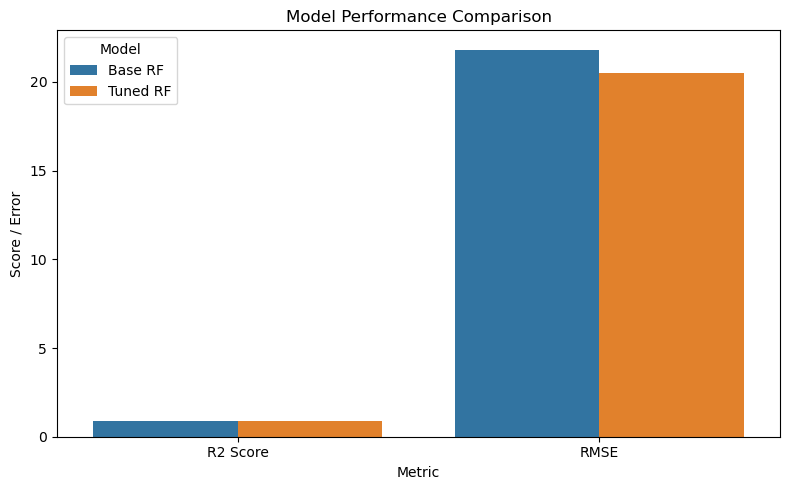


Best Parameters Found:
           Parameter  Value
0          max_depth   10.0
1       max_features    0.7
2  min_samples_split    2.0
3       n_estimators  600.0

Performance:
      Model  R2 Score       RMSE
0   Base RF  0.883381  21.817573
1  Tuned RF  0.897134  20.490732


In [54]:
# -----------------------------------------
# 2. Define parameter grid
# -----------------------------------------
param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2', 0.7],
    'min_samples_split': [2, 4, 6],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

# -----------------------------------------
# 3. Run GridSearchCV
# -----------------------------------------
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# -----------------------------------------
# 4. Evaluate tuned model
# -----------------------------------------
y_pred_base = rf_base.fit(X_train, y_train).predict(X_test)
y_pred_best = best_model.predict(X_test)

r2_base = r2_score(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

# -----------------------------------------
# 5. Plot performance comparison
# -----------------------------------------
plt.figure(figsize=(8, 5))

metrics_df = pd.DataFrame({
    'Model': ['Base RF', 'Tuned RF'],
    'R2 Score': [r2_base, r2_best],
    'RMSE': [rmse_base, rmse_best]
})

sns.barplot(data=metrics_df.melt(id_vars='Model', var_name='Metric'),
            x='Metric', y='value', hue='Model')

plt.title("Model Performance Comparison")
plt.ylabel("Score / Error")
plt.tight_layout()
plt.show()

# -----------------------------------------
# 6. Create table of best hyperparameters
# -----------------------------------------
best_params_df = pd.DataFrame(grid.best_params_.items(), columns=["Parameter", "Value"])
print("\nBest Parameters Found:")
print(best_params_df)

print("\nPerformance:")
print(metrics_df)

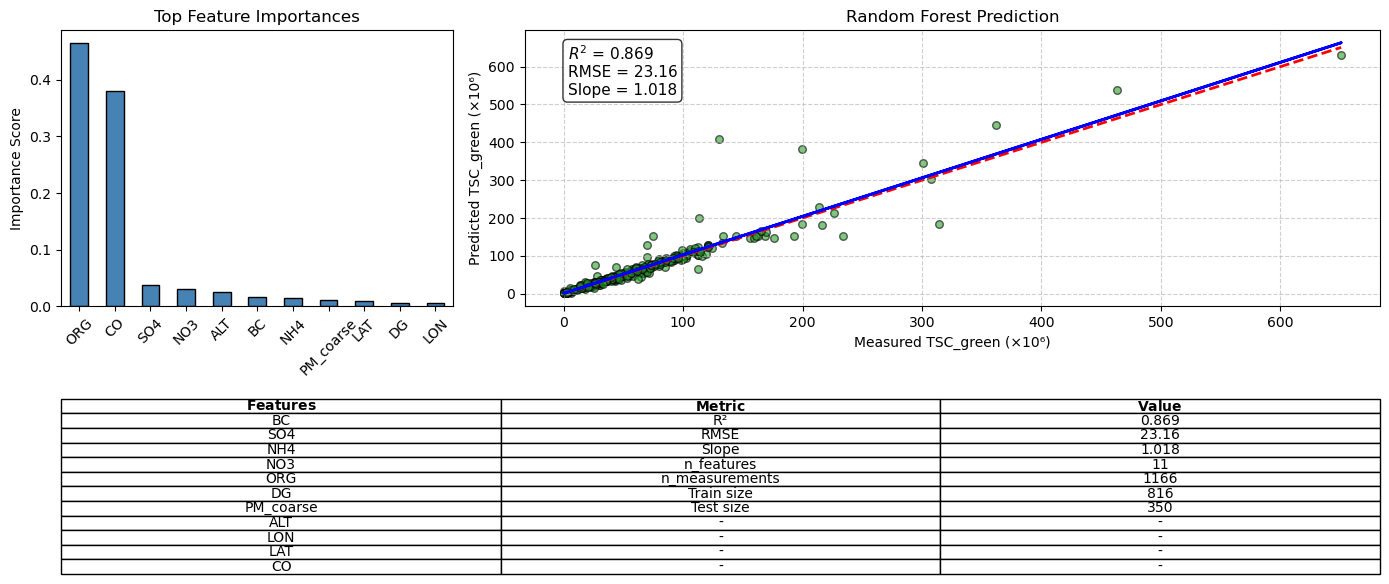

In [68]:
plot_rf_summary(
    top_features=top_features,
    y_test=y_test,
    y_pred=y_pred,
    r2=r2,
    rmse=rmse,
    features=features,
    df_clean=df_clean,
    X_train=X_train,
    X_test=X_test
)

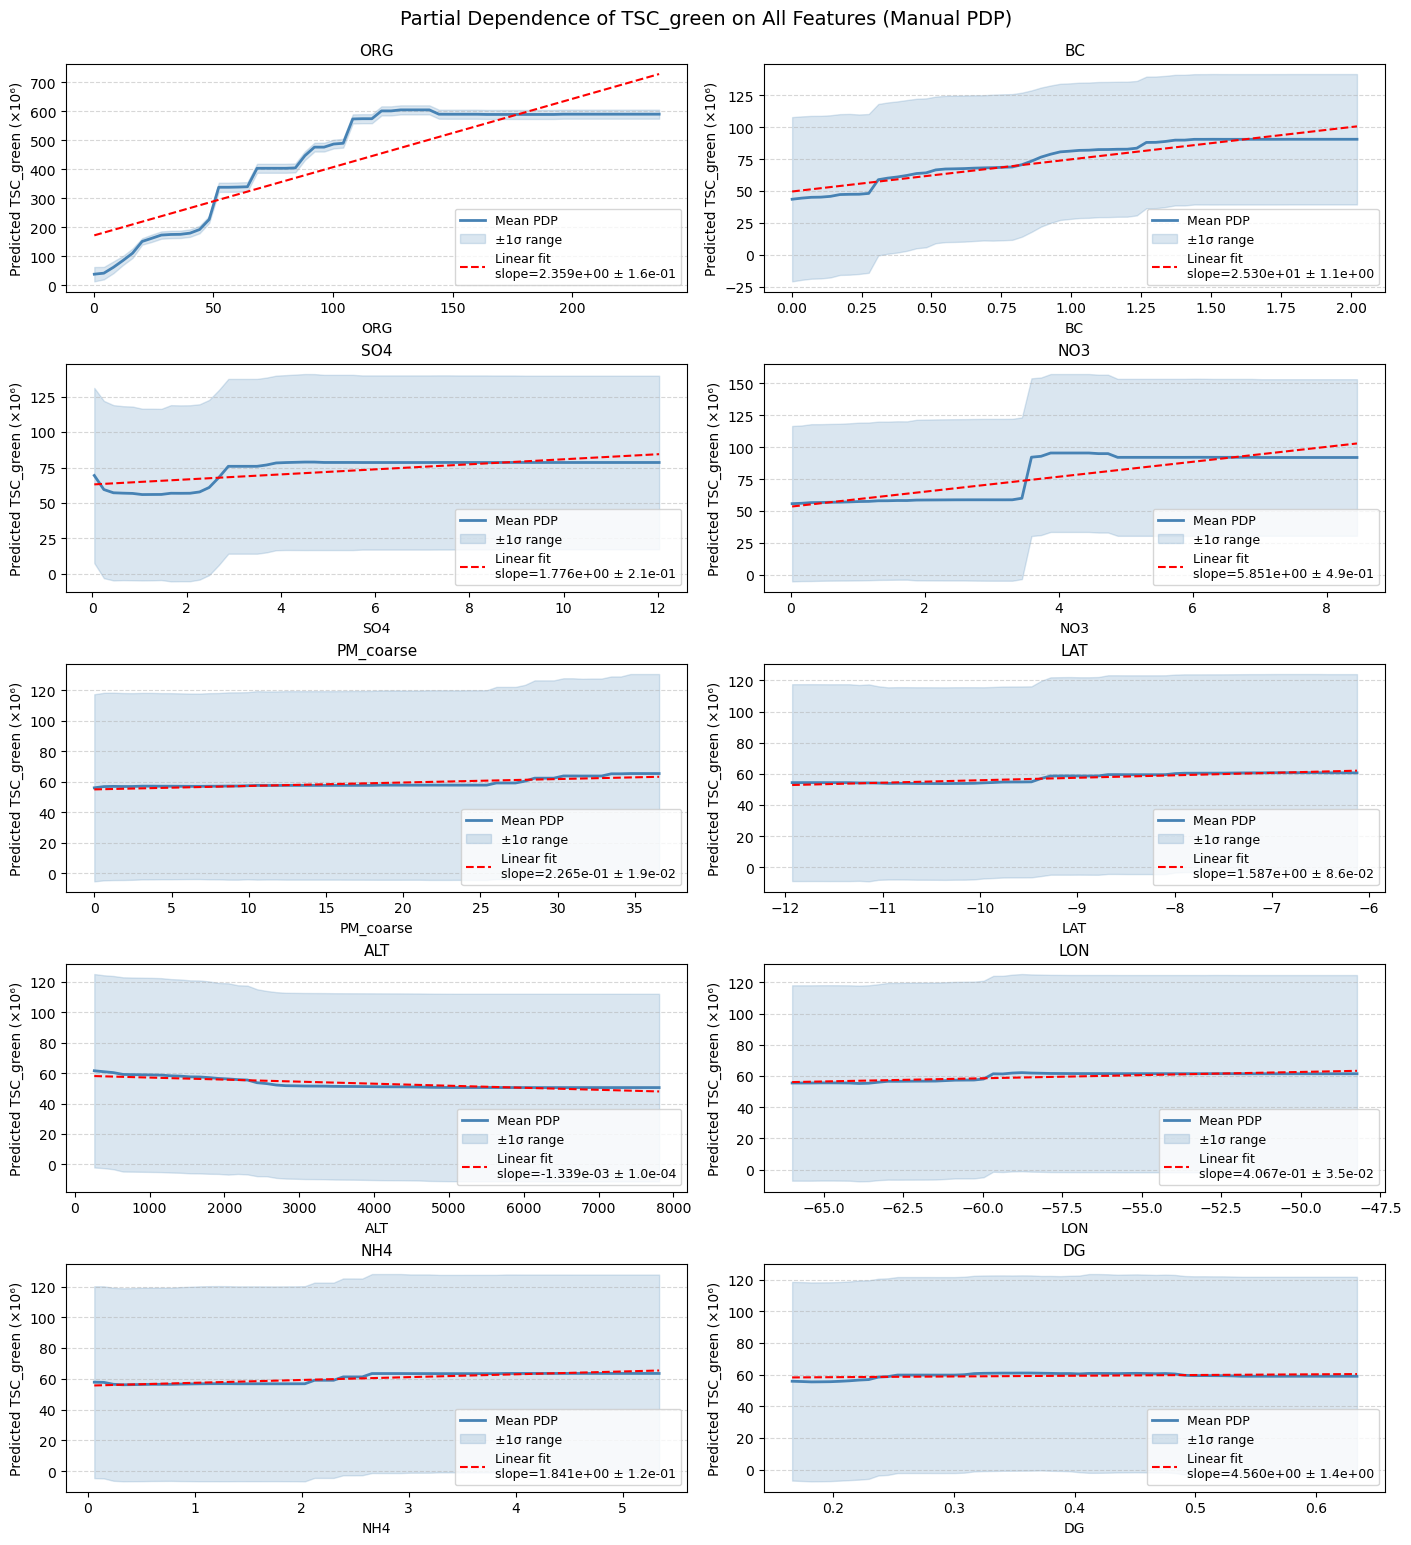

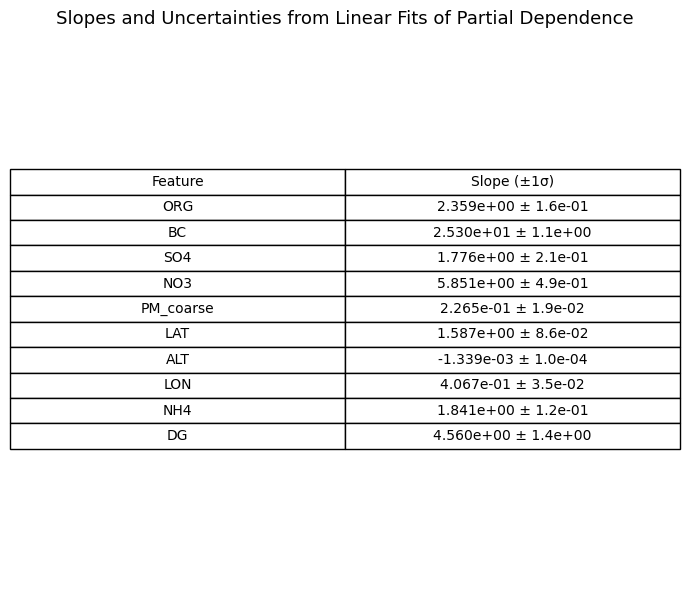

In [66]:
slope_results = plot_manual_pdp_with_slopes(rf, X_train, feat_importances)

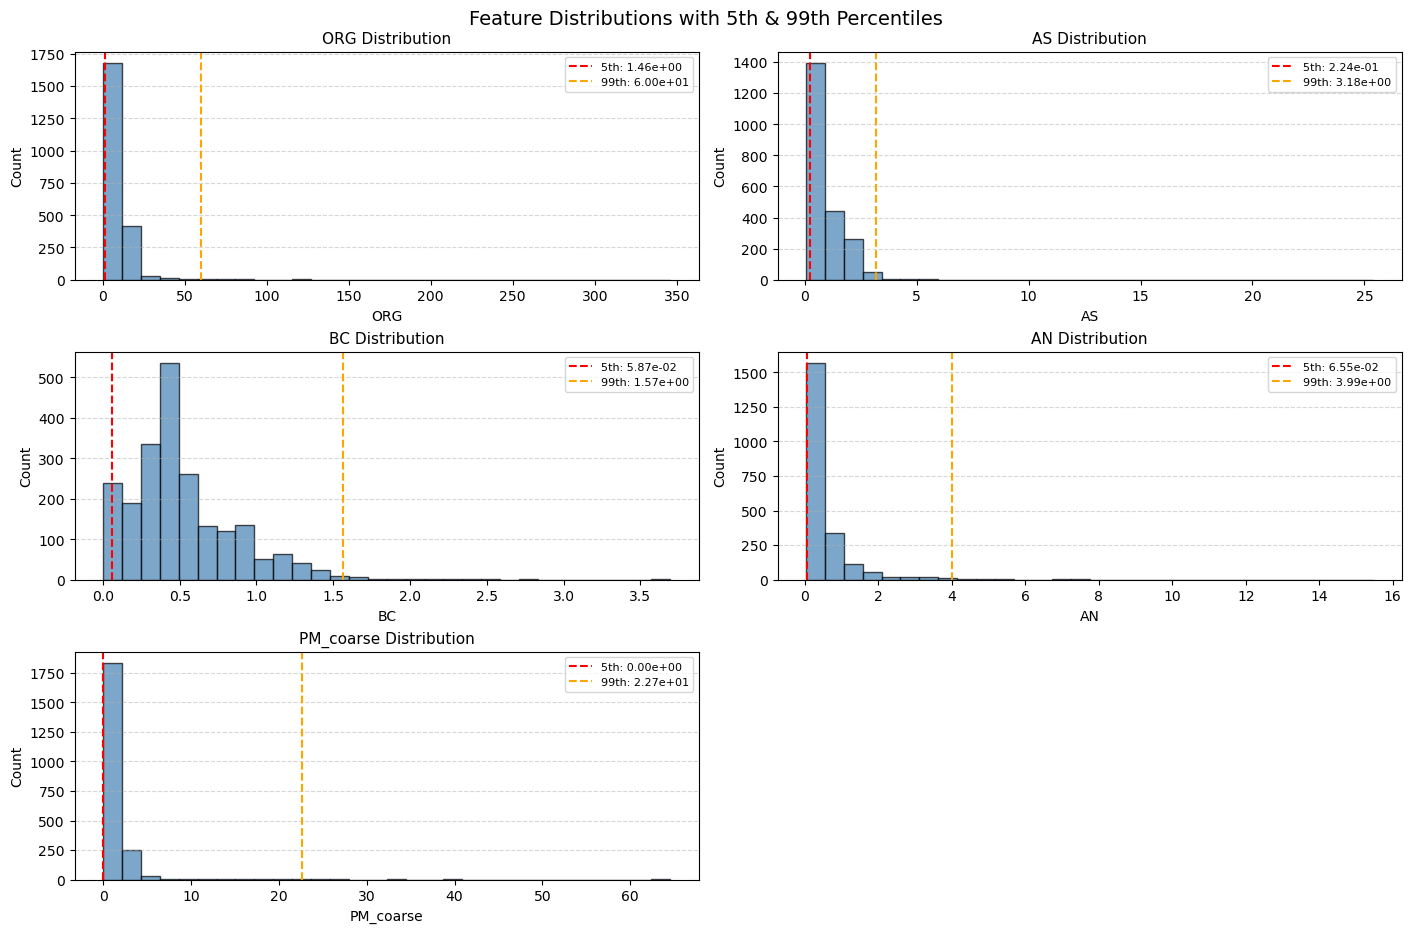

In [73]:
plot_feature_histograms(df_clean, feat_importances, p_low=5, p_high=99)

In [74]:

# Select only the top RF features
top_vars = top_features.index.tolist()

# Prepare X and y for regression
X_reg = df_clean[top_vars]
X_reg = sm.add_constant(X_reg)  # adds intercept term
y_reg = target

# Fit Ordinary Least Squares regression
model = sm.OLS(y_reg, X_reg).fit()

# Print summary with slopes, p-values, R², etc.
print(model.summary())

# You can extract slopes explicitly:
slopes = model.params
print("\nSlopes (coefficients):\n", slopes)

                            OLS Regression Results                            
Dep. Variable:              TSC_green   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     1574.
Date:                Wed, 26 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:25:38   Log-Likelihood:                -10761.
No. Observations:                2164   AIC:                         2.153e+04
Df Residuals:                    2158   BIC:                         2.157e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.5460      1.381      6.188      0.0

In [75]:
robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:              TSC_green   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     266.9
Date:                Wed, 26 Nov 2025   Prob (F-statistic):          1.49e-222
Time:                        14:25:38   Log-Likelihood:                -10761.
No. Observations:                2164   AIC:                         2.153e+04
Df Residuals:                    2158   BIC:                         2.157e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.5460      1.719      4.972      0.0

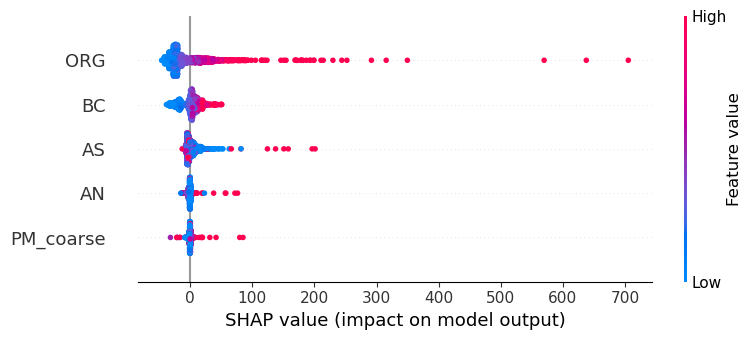

In [76]:
# ============================================
# SHAP ANALYSIS FOR RANDOM FOREST
# ============================================
# Create SHAP explainer for the trained RF model
explainer = shap.TreeExplainer(rf)

# Compute SHAP values for the training data
shap_values = explainer.shap_values(X_train)

# --- Summary Plot (global variable contributions) ---
shap.summary_plot(shap_values, X_train, plot_type="dot")

In [77]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train[top_vars], y_train)

print("Ridge Coefficients:")
for name, coef in zip(top_vars, ridge.coef_):
    print(name, coef)

Ridge Coefficients:
ORG 2.834582198516507
AS -1.079190222187712
BC 35.77923607459176
AN 15.487789590160165
PM_coarse 0.6145417484186436


In [59]:
def filter_flight_data(df_all,low_percentile,high_percentile):
     # Variables to filter
    filter_vars = ['BC', 'SO4', 'NH4', 'ORG', 'NO3' ,'PM_coarse']
    
    for var in filter_vars:
        if var in df_all.columns:
            low, high = np.percentile(df_all[var].dropna(), [low_percentile, high_percentile])
            df_all = df_all[(df_all[var] >= low) & (df_all[var] <= high)]

    return df_all

In [60]:
df_filtered_flight_percentiles = filter_flight_data(df_filtered_flight,0,99)

In [61]:
# -----------------------------
# 1. Prepare dataset
# -----------------------------
df_clean = df_filtered_flight_percentiles.replace([np.inf, -np.inf], np.nan).dropna()

# Features and target
features = df_clean.drop(columns=[
    'TSC_green','TSC_blue','TSC_red','Flight','ABS_PSAP','SIC','CO','ALT','LON','LAT','DG','AS','AN'
])
target = (df_clean['TSC_green']) *1e6
#print(len(target))
# -----------------------------
# 2. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Fit Random Forest
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# -----------------------------
# 4. Evaluate model
# -----------------------------
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# -----------------------------
# 5. Feature importances
# -----------------------------
importances = rf.feature_importances_
feat_importances = pd.Series(importances, index=features.columns)
top_features = feat_importances.sort_values(ascending=False).head(6)

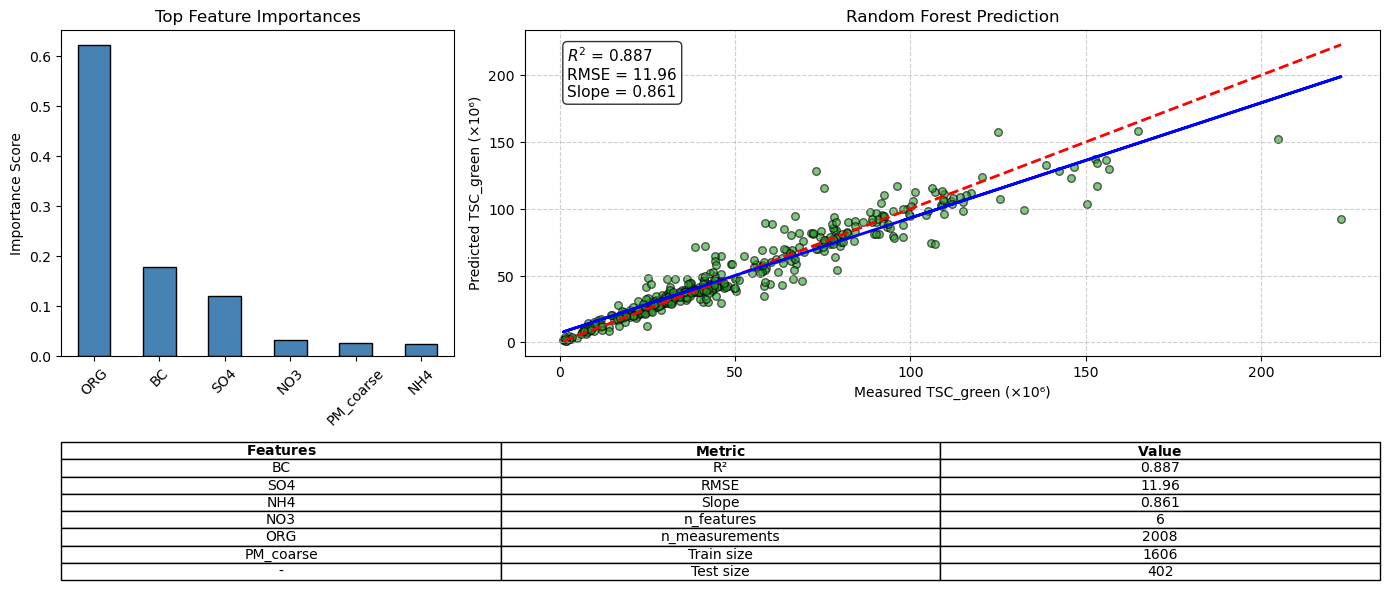

In [62]:
plot_rf_summary(
    top_features=top_features,
    y_test=y_test,
    y_pred=y_pred,
    r2=r2,
    rmse=rmse,
    features=features,
    df_clean=df_clean,
    X_train=X_train,
    X_test=X_test
)

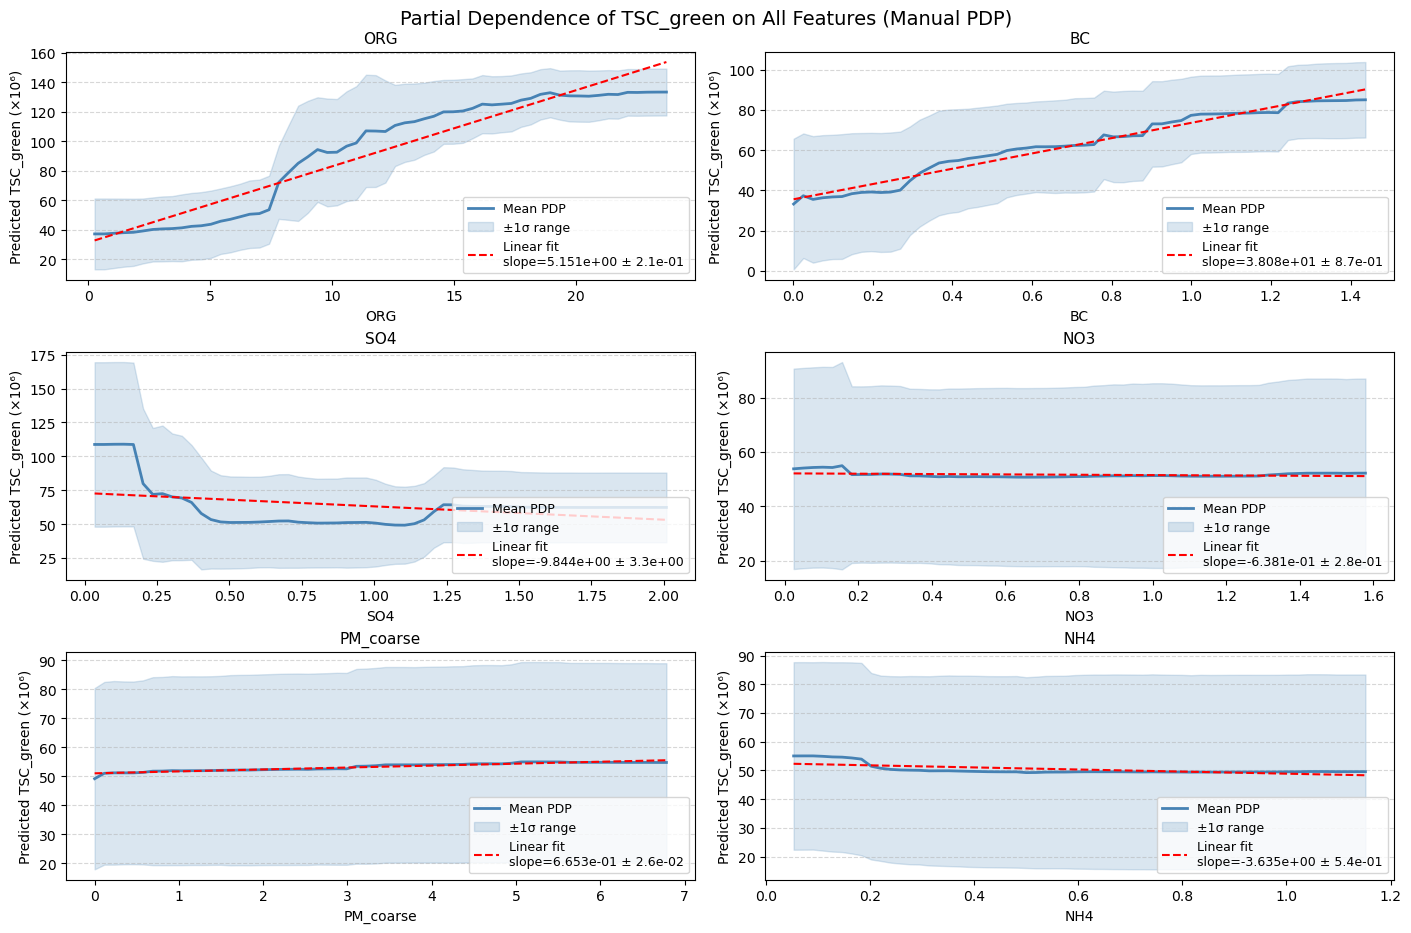

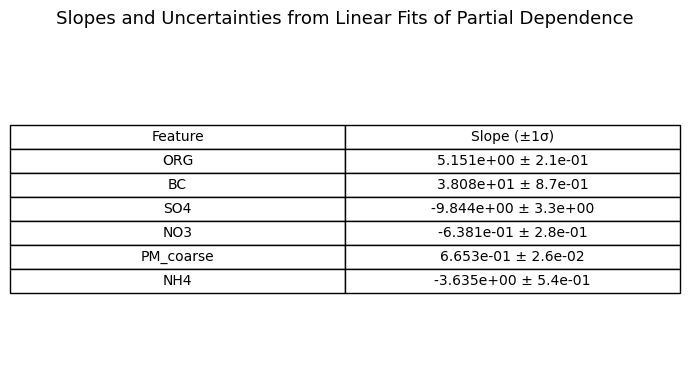

In [63]:
slope_results = plot_manual_pdp_with_slopes(rf, X_train, feat_importances)

In [64]:

# Select only the top RF features
top_vars = top_features.index.tolist()

# Prepare X and y for regression
X_reg = df_clean[top_vars]
X_reg = sm.add_constant(X_reg)  # adds intercept term
y_reg = target

# Fit Ordinary Least Squares regression
model = sm.OLS(y_reg, X_reg).fit()

# Print summary with slopes, p-values, R², etc.
print(model.summary())

# You can extract slopes explicitly:
slopes = model.params
print("\nSlopes (coefficients):\n", slopes)

                            OLS Regression Results                            
Dep. Variable:              TSC_green   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     1006.
Date:                Wed, 26 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:02:12   Log-Likelihood:                -8575.4
No. Observations:                2008   AIC:                         1.716e+04
Df Residuals:                    2001   BIC:                         1.720e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.2980      0.838      7.520      0.0

In [65]:
robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:              TSC_green   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     873.5
Date:                Wed, 26 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:04:10   Log-Likelihood:                -8575.4
No. Observations:                2008   AIC:                         1.716e+04
Df Residuals:                    2001   BIC:                         1.720e+04
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.2980      0.696      9.051      0.0